# Exercise 3 for the class EE-568 Theory and Methods of Reinforcement Learning taught at EPFL in Spring 2026 by Prof. Volkan Cevher

### Names and Sciper numbers

#### Group Member 1:
Name: Kevin Abou Jaoude

Sciper number: 358300

#### Group Member 2:
Name: Fuad Khuri

Sciper number: 357574

#### Group Member 3:
Name: Youssef Dib

Sciper number: 339964

### LLM Usage

You are encouraged **not to use** LLMs or other AI tools so that you can fully engage with and learn the course material. Uploading the full document or copy-pasting the questions into an AI tool are strictly not allowed. 

If you do use them at any point, please clearly and transparently disclose what tool was used, and how in the next cell. 

If AI use is suspected but not clearly explained, we reserve the right to ask follow-up questions to clarify your understanding of the work. 

In [1]:
### Do the imports -- no need to change this
import numpy as np
from typing import List
import matplotlib.pyplot as plt
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'
import sys
sys.path.insert(0, "src/")
from environment import GridWorldEnvironment
from MDPsolver import MDPsolver
from utils import *
from plot import *
%load_ext autoreload
%autoreload 2

***Before starting, we recall the use of the gridworld environment.***

The gridworld environment is instantiated via the class `GridWorldEnvironment`. 

***It takes 4 input values:***
- `reward_mode` : Integer between 0 and 3 for different reward profiles,
- `size`: Gridworld size,
- `prop`: Probability assigned to the event that the agent does not follow the chosen action but another one selected uniformely at random,
- `gamma`: Discount factor of the environment.

***Interface of a Gridworld instance:***
- `print(gridworld.n_states)` # return the number of states
- `print(gridworld.n_actions)` # return the number of actions
- `print(gridworld.r)` # return a matrix where each element indicates the reward corresponding to each (state, action) pair.
- `print(gridworld.gamma)` # return the discount factor
- `print(gridworld.sparseT[action])` # Input: action, Return: a matrix containing the state-to-state transition probabilities for the action passed as input.

<img src="../dynamic_programming/src/vis_gridworld.png" alt="fishy" class="bg-primary" width="400px">

# Ex 1: Prove of the Policy Gradient Theorem via the Performance Difference Lemma (20 points)

Denote $J(\pi) = \langle \mu, V^\pi \rangle$ and recall that the performance difference lemma states
$$
J(\pi) - J(\pi') = \frac{1}{(1-\gamma)}\mathbb{E}_{s \sim \lambda^{\pi'}}[\langle\pi(\cdot|s) - \pi'(\cdot| s) , Q^\pi(s, \cdot) \rangle]
$$
where $\lambda^{\pi'} \in \Delta_{\mathcal{S}\times\mathcal{A}}$ denotes the occupancy measure of the policy $\pi'$.

Now let us consider direct parametization, and compute a partial derivative for the entry of $\pi$ at index $(\bar{s},\bar{a})$:

$$
\frac{\partial J(\pi)}{\partial \pi(\bar{a}|\bar{s})}.
$$

**Questions**

To help you compute this partial derivative, consider the policies $\pi'$ parameterized by some (sufficiently small) $\delta \in \mathbb{R}$ via
$$
    \pi'(a|s) = \begin{cases}
        \pi(\bar{a}|\bar{s}) + \delta \quad (\text{if } (s,a)=(\bar{s},\bar{a}))\\
        \pi(a|s) \quad (\text{else})
    \end{cases}
$$

(1) Argue that
$$
\frac{\partial J(\pi)}{\partial \pi(\bar{a}|\bar{s})} = \frac{1}{(1-\gamma)} \lim_{\delta \rightarrow 0} \frac{\mathbb{E}_{s \sim \lambda^{\pi'}}[\langle\pi(\cdot|s) - \pi'(\cdot| s) , Q^\pi(s, \cdot) \rangle]}{\pi(\bar{a}|\bar{s}) - \pi'(\bar{a}|\bar{s})}.
$$

**Answer**

We start by recalling that the return of a policy is $J(\pi)=\langle\mu,V^{\pi}\rangle$, and that for any reference policy $\pi'$ the performance‑difference lemma tells us
$$
J(\pi)-J(\pi')=\frac{1}{1-\gamma}\,\mathbb{E}_{s\sim\lambda^{\pi'}}\!\bigl[\langle\pi(\cdot|s)-\pi'(\cdot|s),\,Q^{\pi}(s,\cdot)\rangle\bigr],
$$
where $\lambda^{\pi'}\in\Delta_{\mathcal{S}\times\mathcal{A}}$ is the normalized occupancy measure of $\pi'$.

Following the hint, we fix the pair $(\bar s,\bar a)$ and perturb only that single coordinate of $\pi$ by $\delta$, calling the resulting policy $\pi^{\delta}$:
$$
\pi^{\delta}(a|s)=
\begin{cases}
\pi(\bar a|\bar s)+\delta, & (s,a)=(\bar s,\bar a),\\
\pi(a|s), & \text{otherwise}.
\end{cases}
$$
Since nothing else of $\pi$ is touched, $J$, viewed as a function of the entries of $\pi$, satisfies by definition of the partial derivative
$$
\frac{\partial J(\pi)}{\partial\pi(\bar a|\bar s)}=\lim_{\delta\to0}\frac{J(\pi)-J(\pi^{\delta})}{\pi(\bar a|\bar s)-\pi^{\delta}(\bar a|\bar s)}.
$$
We now apply the performance‑difference lemma to the numerator with $\pi'=\pi^{\delta}$:
$$
J(\pi)-J(\pi^{\delta})=\frac{1}{1-\gamma}\,\mathbb{E}_{s\sim\lambda^{\pi^{\delta}}}\!\bigl[\langle\pi(\cdot|s)-\pi^{\delta}(\cdot|s),\,Q^{\pi}(s,\cdot)\rangle\bigr].
$$
Plugging this back and observing that the denominator simplifies to $\pi(\bar a|\bar s)-\pi^{\delta}(\bar a|\bar s)=-\delta$, we directly obtain
$$
\frac{\partial J(\pi)}{\partial\pi(\bar a|\bar s)}=\frac{1}{1-\gamma}\,\lim_{\delta\to0}\frac{\mathbb{E}_{s\sim\lambda^{\pi^{\delta}}}\!\bigl[\langle\pi(\cdot|s)-\pi^{\delta}(\cdot|s),\,Q^{\pi}(s,\cdot)\rangle\bigr]}{\pi(\bar a|\bar s)-\pi^{\delta}(\bar a|\bar s)},
$$
which is exactly the formula we wanted (with $\pi'=\pi^{\delta}$).

(2) Argue that $$\frac{\partial J(\pi)}{\partial \pi(\bar{a}|\bar{s})} = \frac{1}{(1-\gamma)} \lim_{\delta \rightarrow 0} \lambda^{\pi'}(\bar{s}) Q^\pi(\bar{s}, \bar{a}).$$

Hint: Write the expectation in the previous question as a sum and use the fact that $\frac{\pi(a|s) - \pi'(a|s)}{\pi(\bar{a}|\bar{s}) - \pi'(\bar{a}|\bar{s})} = \mathbf{1}_{\{ (\bar{s},\bar{a}) = (s,a) \}}$.

**Answer**

We pick up from the result of part (1):
$$
\frac{\partial J(\pi)}{\partial\pi(\bar a|\bar s)}=\frac{1}{1-\gamma}\lim_{\delta\to0}\frac{\mathbb{E}_{s\sim\lambda^{\pi'}}\!\bigl[\langle\pi(\cdot|s)-\pi'(\cdot|s),\,Q^{\pi}(s,\cdot)\rangle\bigr]}{\pi(\bar a|\bar s)-\pi'(\bar a|\bar s)},\qquad\pi'=\pi^{\delta}.
$$
We first expand the inner product as a sum over actions,
$$
\langle\pi(\cdot|s)-\pi'(\cdot|s),\,Q^{\pi}(s,\cdot)\rangle=\sum_{a\in\mathcal A}\bigl(\pi(a|s)-\pi'(a|s)\bigr)\,Q^{\pi}(s,a),
$$
and then rewrite the expectation as a sum over states, which gives
$$
\mathbb{E}_{s\sim\lambda^{\pi'}}\!\bigl[\langle\pi(\cdot|s)-\pi'(\cdot|s),Q^{\pi}(s,\cdot)\rangle\bigr]=\sum_{s\in\mathcal S}\lambda^{\pi'}(s)\sum_{a\in\mathcal A}\bigl(\pi(a|s)-\pi'(a|s)\bigr)\,Q^{\pi}(s,a).
$$
Dividing through by $\pi(\bar a|\bar s)-\pi'(\bar a|\bar s)$ and pushing it inside the double sum, we get
$$
\frac{\mathbb{E}_{s\sim\lambda^{\pi'}}[\cdots]}{\pi(\bar a|\bar s)-\pi'(\bar a|\bar s)}=\sum_{s}\lambda^{\pi'}(s)\sum_{a}\frac{\pi(a|s)-\pi'(a|s)}{\pi(\bar a|\bar s)-\pi'(\bar a|\bar s)}\,Q^{\pi}(s,a).
$$
Now we observe that, since $\pi'=\pi^{\delta}$ differs from $\pi$ only at the single coordinate $(\bar s,\bar a)$, the ratio inside the sum is $0$ whenever $(s,a)\neq(\bar s,\bar a)$ and $1$ when $(s,a)=(\bar s,\bar a)$. In other words, it is exactly the indicator highlighted in the hint,
$$
\frac{\pi(a|s)-\pi'(a|s)}{\pi(\bar a|\bar s)-\pi'(\bar a|\bar s)}=\mathbf 1_{\{(s,a)=(\bar s,\bar a)\}}.
$$
Substituting this indicator collapses the double sum to a single surviving term,
$$
\sum_{s,a}\lambda^{\pi'}(s)\,\mathbf 1_{\{(s,a)=(\bar s,\bar a)\}}\,Q^{\pi}(s,a)=\lambda^{\pi'}(\bar s)\,Q^{\pi}(\bar s,\bar a).
$$
Reinserting the prefactor from part (1), we conclude
$$
\frac{\partial J(\pi)}{\partial\pi(\bar a|\bar s)}=\frac{1}{1-\gamma}\,\lim_{\delta\to0}\lambda^{\pi'}(\bar s)\,Q^{\pi}(\bar s,\bar a),
$$
which is the desired identity.

(3) Conclude that $$\frac{\partial J(\pi)}{\partial \pi(\bar{a}|\bar{s})} = \frac{1}{(1-\gamma)} \lambda^{\pi}(\bar{s}) Q^\pi(\bar{s}, \bar{a})$$
for the direct parameterization. 

**Answer**

We observe that the perturbed policy $\pi'=\pi^{\delta}$ differs from $\pi$ only by an infinitesimal change at the single coordinate $(\bar s,\bar a)$. Since the occupancy measure depends continuously on the policy — recall it can be written as
$$
\lambda^{\pi}=(1-\gamma)\sum_{t\ge 0}\gamma^{t}\,\mu^{\top}P_{\pi}^{t},
$$
and each term is continuous in $\pi$ — we can pass the limit through and get
$$
\lim_{\delta\to0}\lambda^{\pi^{\delta}}(\bar s)=\lambda^{\pi}(\bar s).
$$
Plugging this into the limit obtained in part (2) we then conclude
$$
\frac{\partial J(\pi)}{\partial\pi(\bar a|\bar s)}=\frac{1}{1-\gamma}\,\lim_{\delta\to0}\lambda^{\pi^{\delta}}(\bar s)\,Q^{\pi}(\bar s,\bar a)=\frac{1}{1-\gamma}\,\lambda^{\pi}(\bar s)\,Q^{\pi}(\bar s,\bar a),
$$
which is exactly the identity we wanted to prove. So under the direct parameterization, the gradient of $J$ with respect to a single probability entry is — up to the factor $\tfrac{1}{1-\gamma}$ — the occupancy weight of $\bar s$ under $\pi$ multiplied by the action‑value $Q^{\pi}(\bar s,\bar a)$.

(4) Prove that for a general parametrization, it holds that
$$
\nabla_\theta J(\pi_\theta) = \frac{1}{(1-\gamma)} \sum_{\bar{s},\bar{a}} \lambda^{\pi}(\bar{s}, \bar{a}) Q^\pi(\bar{s}, \bar{a}) \nabla_{\theta} ( \log \pi_\theta(\bar{a}|\bar{s}))
$$

Hint: Use the chain rule to write $$ \nabla_\theta J(\pi_\theta)  = \sum_{\bar{s},\bar{a}} \frac{\partial J(\pi)}{\partial \pi_\theta(\bar{a}|\bar{s})} \nabla_{\theta} \pi_\theta(\bar{a}|\bar{s}), $$
and then use the fact that $\lambda^{\pi}(\bar{s},\bar{a}) = \lambda^{\pi}(\bar{s}) \pi(\bar{a}|\bar{s})$.

**Answer**

Following the hint, we apply the chain rule and write
$$
\nabla_\theta J(\pi_\theta)=\sum_{\bar s,\bar a}\frac{\partial J(\pi_\theta)}{\partial\pi_\theta(\bar a|\bar s)}\,\nabla_\theta\pi_\theta(\bar a|\bar s).
$$
From part (3) we already know that $\displaystyle\frac{\partial J(\pi_\theta)}{\partial\pi_\theta(\bar a|\bar s)}=\frac{1}{1-\gamma}\,\lambda^{\pi_\theta}(\bar s)\,Q^{\pi_\theta}(\bar s,\bar a)$, so plugging it in gives
$$
\nabla_\theta J(\pi_\theta)=\frac{1}{1-\gamma}\sum_{\bar s,\bar a}\lambda^{\pi_\theta}(\bar s)\,Q^{\pi_\theta}(\bar s,\bar a)\,\nabla_\theta\pi_\theta(\bar a|\bar s).
$$
We now invoke the standard log‑derivative identity $\nabla_\theta\pi_\theta(\bar a|\bar s)=\pi_\theta(\bar a|\bar s)\,\nabla_\theta\log\pi_\theta(\bar a|\bar s)$ (valid wherever $\pi_\theta(\bar a|\bar s)>0$), and combine it with the factorization $\lambda^{\pi_\theta}(\bar s,\bar a)=\lambda^{\pi_\theta}(\bar s)\,\pi_\theta(\bar a|\bar s)$ stated in the hint:
$$
\lambda^{\pi_\theta}(\bar s)\,\nabla_\theta\pi_\theta(\bar a|\bar s)=\lambda^{\pi_\theta}(\bar s)\,\pi_\theta(\bar a|\bar s)\,\nabla_\theta\log\pi_\theta(\bar a|\bar s)=\lambda^{\pi_\theta}(\bar s,\bar a)\,\nabla_\theta\log\pi_\theta(\bar a|\bar s).
$$
Substituting back, we obtain the policy gradient theorem:
$$
\boxed{\;\nabla_\theta J(\pi_\theta)=\frac{1}{1-\gamma}\sum_{\bar s,\bar a}\lambda^{\pi_\theta}(\bar s,\bar a)\,Q^{\pi_\theta}(\bar s,\bar a)\,\nabla_\theta\log\pi_\theta(\bar a|\bar s).\;}
$$

# Ex 2: Natural Policy Gradient with softmax parameterization (20 points)

Recall that the iterates $\{\pi^t\}^{\infty}_{t=1}$ produced by NPG read as follows:
$$
\pi^{t+1}(a|s) = \frac{\pi^t(a|s)e^{\eta Q^{\pi^t}(s,a) }}{\sum_{a'} \pi^t(a'|s) e^{\eta Q^{\pi^t}(s,a')}}.
$$

Implement NPG for an arbitrary step size $\eta$. Please note that $e^{\eta Q^{\pi^t}(s,a)}$ can be zero, account for that in your implementation.

***Hint:*** When computing the exponential update, think about numerical stability. You can subtract the same constant from all values (e.g., the maximum) before applying exp.

In [2]:
def evaluate_policy(pi, env, tol=1e-10):
    """Implementation of policy evaluation through iteratively applying using a certain policy 
    Args:
        pi: a policy stochastic passed with shape n_states times n_actions
        env: environment
        tol: a scalar to dermerminate whether the policy evaluation convergences
    Returns:
        v: an array with the values of the actions chosen
        q: an array with the q values    
    """
    v = np.zeros(env.n_states)
    q = np.zeros((env.n_states, env.n_actions))
    while True:
        v_old = np.copy(v)
        for a in range(env.n_actions):
            q[:, a] = env.r[:, a] + env.gamma * env.sparseT[a].dot(v)
        for s in range(env.n_states):
            v[s] = q[s].dot(pi[s])
        if np.linalg.norm(v - v_old) < tol:
            break
    return v, q

def npg_update(q, eta, old_policy):
    """Implementation of a greedy approach to choose policies (policy improvement)
    Args:
        q: q values obtained from evaluating the policies
    Returns:
        new_policy: the updates policy
    """
    policy = np.zeros_like(q)
    for s in range(q.shape[0]):
        # Numerically stable exponential: subtract the max before exponentiating
        shifted = eta * q[s] - np.max(eta * q[s])
        policy[s] = old_policy[s] * np.exp(shifted)
        total = np.sum(policy[s])
        if total == 0:
             policy[s] = np.ones(q.shape[1])/q.shape[1]
        else:
            policy[s] = policy[s] / total
    return policy

def get_greedy_policy(q):
    """Implementation of a greedy approach to choose policies (policy improvement)
    Args:
        q: q values obtained from evaluating the policies
    Returns:
        policy: greedy policy (list)
    """
    policy = np.zeros_like(q)
    for s in range(q.shape[0]):
        policy[s,np.argmax(q[s,:])] = 1
    return policy

In [3]:
def NPG(env, eta): # apply NPG iterations for 30 steps
    vs = []
    policies = []
    v = np.zeros(env.n_states)
    q = np.zeros((env.n_states, env.n_actions))
    pi = np.ones_like(q)/env.n_actions
    for k in range(30):
        v_old = np.copy(v)
        v, q = evaluate_policy(pi, env)
        if eta < np.inf:
            pi = npg_update(q, eta, pi)
        else:
            pi = get_greedy_policy(q)
        vs.append(v)
        policies.append(pi)
    return vs, policies

Now, we run NPG for different stepsizes in the usual gridworld environment

In [4]:
reward_mode = 2
size = 10 
prop = 0
gamma=0.99
gridworld = GridWorldEnvironment(reward_mode, size, prop=0, gamma=gamma)
mu = np.ones(gridworld.n_states)/gridworld.n_states
etas = [1e-3, 1e-2, 1e-1, 1, 100, 1e7, np.inf]
v_different_etas = []
pi_different_etas = []
for eta in etas:
    values_pi, policies = NPG(gridworld, eta=eta)
    v_different_etas.append(values_pi)
    pi_different_etas.append(policies)

In [5]:
solver = MDPsolver(gridworld)
solver.value_iteration()

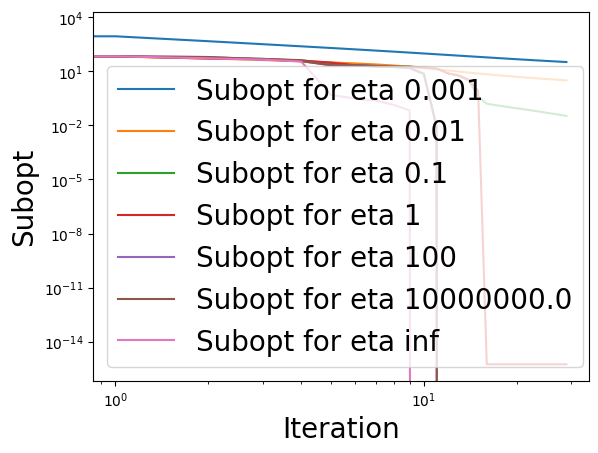

In [6]:
# TODO: if this plot appears with a too large legend, rerun this line once more
plot_log_lines([np.array([mu.dot(solver.v - v) for v in v_different_etas[i]]) for i, _ in enumerate(etas)], [f"Subopt for eta {eta}" for eta in etas], ["Iteration", "Subopt"], "figs", "NPG.pdf", show = True)

**Question**

Show that NPG with $\eta = \infty$ coincides with Policy Iteration (PI).

More formally: Assuming that $a^\star_s := \mathrm{argmax}_a Q^{\pi^t}(s,a)$ is unique for all $s$, prove that $$ \lim_{\eta \rightarrow \infty} \frac{\pi^t(a|s)e^{\eta Q^{\pi^t}(s,a) }}{\sum_{a'} \pi^t(a'|s) e^{\eta Q^{\pi^t}(s,a')}} = \begin{cases} 1 \quad \text{if} \quad a = a^\star_s \\ 0 \quad \text{otherwise} \end{cases},$$
and explain how this relates to PI.

**Answer**

We assume that for every state $s$ the $Q$‑values of the current policy $\pi^{t}$ admit a unique maximiser $a_s^\star=\arg\max_a Q^{\pi^t}(s,a)$. Since the exponential is strictly increasing, the action that maximises $Q^{\pi^t}(s,\cdot)$ is also the one that maximises $\exp(\eta Q^{\pi^t}(s,\cdot))$. Hence, in the NPG update
$$
\pi^{t+1}(a\mid s)=\frac{\pi^{t}(a\mid s)\,e^{\eta Q^{\pi^t}(s,a)}}{\sum_{a'}\pi^{t}(a'\mid s)\,e^{\eta Q^{\pi^t}(s,a')}},
$$
we observe that as $\eta\to\infty$ the denominator is dominated by the single term corresponding to $a_s^\star$:
$$
\lim_{\eta\to\infty}\sum_{a'}\pi^{t}(a'\mid s)\,e^{\eta Q^{\pi^t}(s,a')}\;\sim\;\pi^{t}(a_s^\star\mid s)\,e^{\eta Q^{\pi^t}(s,a_s^\star)}.
$$

We then compare the two possible numerators. When $a=a_s^\star$, the fraction collapses to $1$:
$$
\lim_{\eta\to\infty}\frac{\pi^{t}(a_s^\star\mid s)\,e^{\eta Q^{\pi^t}(s,a_s^\star)}}{\pi^{t}(a_s^\star\mid s)\,e^{\eta Q^{\pi^t}(s,a_s^\star)}}=1.
$$
On the other hand, if $a\neq a_s^\star$ the ratio of exponentials is strictly smaller than $1$, and raising it to an unbounded $\eta$ drives the whole expression to $0$:
$$
\frac{e^{Q^{\pi^t}(s,a)}}{e^{Q^{\pi^t}(s,a_s^\star)}}<1\quad\Longrightarrow\quad\lim_{\eta\to\infty}\!\left(\frac{e^{Q^{\pi^t}(s,a)}}{e^{Q^{\pi^t}(s,a_s^\star)}}\right)^{\!\eta}=0,
$$
hence
$$
\lim_{\eta\to\infty}\frac{\pi^{t}(a\mid s)\,e^{\eta Q^{\pi^t}(s,a)}}{\pi^{t}(a_s^\star\mid s)\,e^{\eta Q^{\pi^t}(s,a_s^\star)}}=0.
$$
Collecting the two cases, we conclude that
$$
\lim_{\eta\to\infty}\pi^{t+1}(a\mid s)=\begin{cases}1 & a=a_s^\star,\\[2pt]0 & a\neq a_s^\star.\end{cases}
$$
In other words, with an infinite step size NPG produces a policy that, in every state, deterministically picks the action maximising $Q^{\pi^t}$. This is exactly the greedy policy‑improvement step of classical Policy Iteration, so NPG with $\eta=\infty$ coincides with PI.

**Question**

Is this observation in line with the empirical results in the plot above? I.e., is the plot for $\eta = \infty$ as you would expect it for PI?

**Answer**

Yes, the plot for $\eta=\infty$ is consistent with what we expect from Policy Iteration. We observe a very rapid decrease of the suboptimality, much faster than for the smaller step sizes. This is in line with the previous question: with $\eta=\infty$ the NPG update reduces to the greedy step of PI, so the policy immediately commits to the best action in each state and the value gap shrinks abruptly, producing the steep curve we see in the plot.

# Ex 2.2 Slow Changing Property of NPG

In this exercise you will investigate by how much consecutive iterates $\pi^t$ and $\pi^{t+1}$ produced by NPG differ and how this distance is controlled by the step size $\eta$.

Plot $$\max_{s \in \mathcal{S}} || \pi^{t+1}(a|s) - \pi^t(a|s) ||_1$$ for different values of $\eta$.

In [7]:
def compute_policy_variation(policies):
    variation = []
    for pi, pip in zip(policies[1:], policies[:-1]):
        variation.append(np.max([np.sum(np.abs(pip[s, :] - pi[s, :])) for s in range(pi.shape[0])]))
    return variation

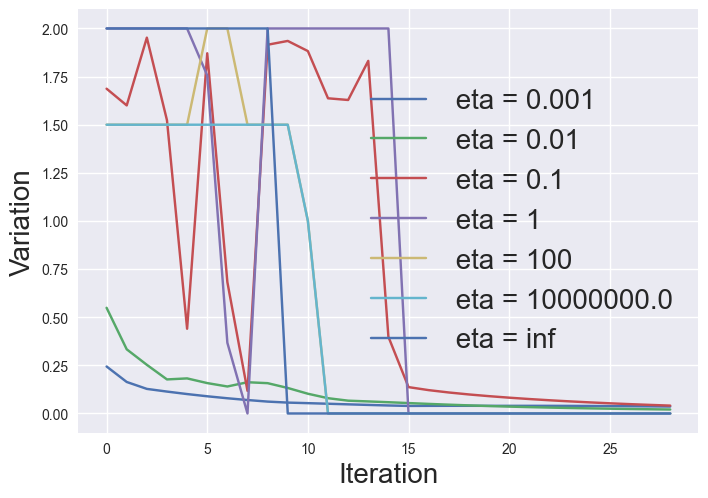

In [8]:
plot_lines(np.array([ compute_policy_variation(np.array(pi_different_etas)[i])
                           for i, _ in enumerate(etas)]), 
               [f" eta = {eta}" for eta in etas], 
               ["Iteration", "Variation"], "figs", "NPG.pdf", show = True)

**Question**

Empirically, is the largest change (among all iterations) between consecutive iterations is larger for smaller or large values of $\eta$?

From the plot we observe that the largest change between consecutive policies occurs for the **larger** values of $\eta$. This makes sense: as $\eta$ grows (and especially as it approaches infinity), the NPG update tends towards the greedy policy‑improvement step of Policy Iteration, so a single iteration can switch the probability mass abruptly from one action to another, with an $L_1$ variation that can reach up to $2$. By contrast, for small $\eta$ the exponential factor $e^{\eta Q^{\pi^t}(s,a)}$ stays close to $1$, the new policy stays close to the previous one, and the variation between consecutive iterates remains small.

## Some Theory to Motivate the Observation Above

**Question**

Our goal is to prove that $$ || \pi^{t+1}(\cdot|s) - \pi^t(\cdot|s) ||_1 \leq \frac{\eta}{1 - \gamma} \quad \forall s \in \mathcal{S}, \forall t \in [T].$$

We guide you towards this result by breaking the proof into small steps.

1) Prove that $$ \frac{1}{2} || \pi^{t+1}(s) - \pi^t(s) ||^2_1 \leq \mathbb{E}_{a \sim \pi^{t+1}(\cdot|s)}[\eta Q^{\pi^t}(s,a)] - \log \bigg(\sum_{a'\in\mathcal{A}} \pi^t(a'|s) \exp (\eta Q^{\pi^t}(s,a'))\bigg) $$

Hint: First apply Pinkser's inequality https://en.wikipedia.org/wiki/Pinsker%27s_inequality to prove that $$\frac{1}{2} || \pi^{t+1}(s) - \pi^t(s) ||^2_1 \leq KL(\pi^{t+1}(s)||\pi^t(s)), $$ then plug in the formula for $\pi^{t+1}$ into the KL term.

**Answer**

Fix any state $s$ and abbreviate $\pi^{t+1}(\cdot\mid s)$ by $P$ and $\pi^{t}(\cdot\mid s)$ by $Q$. We start by applying Pinsker's inequality, which gives
$$
\tfrac12\|P-Q\|_1^{2}\le D_{\mathrm{KL}}(P\,\|\,Q),
$$
so the desired $L_1$ control reduces to bounding the KL term. We then plug in the NPG update
$$
\pi^{t+1}(a\mid s)=\frac{\pi^{t}(a\mid s)\,\exp\bigl(\eta\,Q^{\pi^t}(s,a)\bigr)}{\displaystyle\sum_{a'}\pi^{t}(a'\mid s)\,\exp\bigl(\eta\,Q^{\pi^t}(s,a')\bigr)},
$$
and denote the normaliser in the denominator by $Z(s)$. We then compute
$$
\begin{aligned}
D_{\mathrm{KL}}\!\bigl(\pi^{t+1}(\cdot\mid s)\,\|\,\pi^{t}(\cdot\mid s)\bigr)
&=\sum_{a}\pi^{t+1}(a\mid s)\,\log\frac{\pi^{t+1}(a\mid s)}{\pi^{t}(a\mid s)}\\[2pt]
&=\sum_{a}\pi^{t+1}(a\mid s)\,\log\frac{\pi^{t}(a\mid s)\,e^{\eta Q^{\pi^t}(s,a)}/Z(s)}{\pi^{t}(a\mid s)}\\[2pt]
&=\sum_{a}\pi^{t+1}(a\mid s)\,\bigl[\eta\,Q^{\pi^t}(s,a)-\log Z(s)\bigr]\\[2pt]
&=\mathbb E_{a\sim\pi^{t+1}(\cdot\mid s)}\!\bigl[\eta\,Q^{\pi^t}(s,a)\bigr]-\log Z(s).
\end{aligned}
$$
Combining this expression with the Pinsker bound yields
$$
\frac12\bigl\|\pi^{t+1}(\cdot\mid s)-\pi^{t}(\cdot\mid s)\bigr\|_1^{2}\;\le\;\mathbb E_{a\sim\pi^{t+1}(\cdot\mid s)}\!\bigl[\eta\,Q^{\pi^t}(s,a)\bigr]-\log\!\Bigl(\sum_{a'}\pi^{t}(a'\mid s)\,e^{\eta Q^{\pi^t}(s,a')}\Bigr),
$$
which is exactly the inequality we wanted to prove.

2) Prove that 
$$
\sum_{a\in \mathcal{A}} \pi^{t+1}(a|s) \exp(- \eta Q^{\pi^t}(s,a)) = \frac{1}{\sum_{a'\in \mathcal{A}} \pi^t(a|s) \exp(\eta Q^{\pi^t}(s,a) )}.
$$

**Answer**

We start from the NPG update rule
$$
\pi^{t+1}(a\mid s)=\frac{\pi^{t}(a\mid s)\,e^{\eta Q^{\pi^t}(s,a)}}{\displaystyle\sum_{a'}\pi^{t}(a'\mid s)\,e^{\eta Q^{\pi^t}(s,a')}}.
$$
We then multiply both sides by $\exp\!\bigl(-\eta Q^{\pi^t}(s,a)\bigr)$ and sum over $a$:
$$
\begin{aligned}
\sum_{a}\pi^{t+1}(a\mid s)\,e^{-\eta Q^{\pi^t}(s,a)}
&=\sum_{a}\frac{\pi^{t}(a\mid s)\,e^{\eta Q^{\pi^t}(s,a)}}{\sum_{a'}\pi^{t}(a'\mid s)\,e^{\eta Q^{\pi^t}(s,a')}}\,e^{-\eta Q^{\pi^t}(s,a)}\\[4pt]
&=\frac{\sum_{a}\pi^{t}(a\mid s)}{\sum_{a'}\pi^{t}(a'\mid s)\,e^{\eta Q^{\pi^t}(s,a')}}.
\end{aligned}
$$
We now observe that, since $\pi^{t}(\cdot\mid s)$ is a probability distribution, the numerator simplifies to $1$, and we conclude
$$
\sum_{a}\pi^{t+1}(a\mid s)\,e^{-\eta Q^{\pi^t}(s,a)}=\frac{1}{\displaystyle\sum_{a'}\pi^{t}(a'\mid s)\,e^{\eta Q^{\pi^t}(s,a')}},
$$
which is the identity we wanted, valid for every state $s$.

3) Using the results in 1) and 2) prove that 

$$ \frac{1}{2} || \pi^{t+1}(s) - \pi^t(s) ||^2_1 \leq \mathbb{E}_{a \sim \pi^{t+1}(\cdot|s)}[\eta Q^{\pi^t}(s,a)] + \log \bigg(\sum_{a'\in\mathcal{A}} \pi^{t+1}(a'|s) \exp (-\eta Q^{\pi^t}(s,a'))\bigg). $$

**Answer**

We start from the inequality already obtained in part 1,
$$
\frac12\bigl\|\pi^{t+1}(s)-\pi^{t}(s)\bigr\|_1^{2}\;\le\;\mathbb E_{a\sim\pi^{t+1}(\cdot\mid s)}\!\bigl[\eta\,Q^{\pi^t}(s,a)\bigr]-\log\!\Bigl(\sum_{a'}\pi^{t}(a'\mid s)\,e^{\eta Q^{\pi^t}(s,a')}\Bigr),
$$
and define the normalising constant
$$
Z(s):=\sum_{a'}\pi^{t}(a'\mid s)\,e^{\eta Q^{\pi^t}(s,a')}.
$$
Part 2 then tells us that
$$
\sum_{a}\pi^{t+1}(a\mid s)\,e^{-\eta Q^{\pi^t}(s,a)}=\frac{1}{Z(s)}.
$$
Taking logarithms on both sides yields
$$
-\log Z(s)=\log\!\Bigl(\sum_{a}\pi^{t+1}(a\mid s)\,e^{-\eta Q^{\pi^t}(s,a)}\Bigr).
$$
We now substitute this expression for $-\log Z(s)$ in the bound from part 1, and we conclude
$$
\frac12\bigl\|\pi^{t+1}(s)-\pi^{t}(s)\bigr\|_1^{2}\;\le\;\mathbb E_{a\sim\pi^{t+1}(\cdot\mid s)}\!\bigl[\eta\,Q^{\pi^t}(s,a)\bigr]+\log\!\Bigl(\sum_{a'}\pi^{t+1}(a'\mid s)\,e^{-\eta Q^{\pi^t}(s,a')}\Bigr),
$$
which is exactly the inequality we were asked to prove.

4) Using Hoeffding's Lemma https://en.wikipedia.org/wiki/Hoeffding%27s_lemma (on the sum in the log term!) and the fact that $$-\frac{1}{1-\gamma} \leq Q^{\pi^t}(s,a) \leq \frac{1}{1-\gamma},$$ conclude that 
$$\frac{1}{2} || \pi^{t+1}(s) - \pi^t(s) ||^2_1 \leq \frac{\eta^2}{2 (1 - \gamma)^2}.$$

**Answer**

We start from the inequality obtained in part 3,
$$
\frac12\|\pi^{t+1}(s)-\pi^{t}(s)\|_1^{2}\;\le\;\mathbb E_{a\sim\pi^{t+1}(\cdot\mid s)}\!\bigl[\eta\,Q^{\pi^t}(s,a)\bigr]+\log\!\Bigl(\sum_{a}\pi^{t+1}(a\mid s)\,e^{-\eta Q^{\pi^t}(s,a)}\Bigr),
$$
and we denote by $X$ the random variable $Q^{\pi^t}(s,a)$ when $a\sim\pi^{t+1}(\cdot\mid s)$. Since every action‑value lies in the interval $[-\tfrac{1}{1-\gamma},\tfrac{1}{1-\gamma}]$, we have $a\le X\le b$ almost surely with $a=-\tfrac{1}{1-\gamma}$ and $b=\tfrac{1}{1-\gamma}$, so $b-a=\tfrac{2}{1-\gamma}$. We then apply Hoeffding's lemma with $\lambda=-\eta$, which gives
$$
\mathbb E\bigl[e^{-\eta X}\bigr]\;\le\;\exp\!\Bigl(-\eta\,\mathbb E[X]+\tfrac{\eta^{2}(b-a)^{2}}{8}\Bigr)\;=\;\exp\!\Bigl(-\eta\,\mathbb E[X]+\tfrac{\eta^{2}}{2(1-\gamma)^{2}}\Bigr).
$$
Taking the logarithm of this expectation, we control the log‑sum term as
$$
\log\!\Bigl(\sum_{a}\pi^{t+1}(a\mid s)\,e^{-\eta Q^{\pi^t}(s,a)}\Bigr)=\log\mathbb E\bigl[e^{-\eta X}\bigr]\;\le\;-\eta\,\mathbb E[X]+\frac{\eta^{2}}{2(1-\gamma)^{2}}.
$$
Plugging this estimate back into the bound from part 3 cancels the linear terms in $\eta\,\mathbb E[X]$ exactly, and we conclude
$$
\frac12\|\pi^{t+1}(s)-\pi^{t}(s)\|_1^{2}\;\le\;\frac{\eta^{2}}{2(1-\gamma)^{2}},
$$
which is the desired result. Taking square roots, we recover the slow‑changing property
$$
\|\pi^{t+1}(\cdot\mid s)-\pi^{t}(\cdot\mid s)\|_1\;\le\;\frac{\eta}{1-\gamma},\qquad\forall s\in\mathcal S,\ \forall t\in[T].
$$

# Ex 3: OPPO: The importance of Exploration in Policy Gradient (20 points)

In this exercise, we will investigate how crucial it is to perform exploration. That is, adding bonuses to avoid suffering the mismatch coefficients in the convergence bounds.

Let us recall that the standard sample based version of NPG suffers the mismatch coeffcients in the bounds (see Slide 22 in Lecture 5). Those are avoided by OPPO ( See slide 30 in Lecture 5 ).

**To see clearly the advatange of OPPO we will consider an MDP with unbounded mismatch coefficients**

**Question: example of unbounded mismatch coefficients**

Consider a 10 x 10 gridworld, the initial state is always the bottom right corner, i.e. the initial distribution $\mu$ equals $1$ at this starting state and it is zero everywhere else. Can you compute a finite bound for 
$$\max_\pi \max_{s \in \mathcal{S}} \bigg |\frac{\lambda^\pi(s)}{\mu(s)} \bigg|,$$
i.e. the mismatch coefficient? If not, argue for which reason.

**Answer**



We want to assess whether the mismatch coefficient
$$
\max_\pi\,\max_{s\in\mathcal S}\left|\frac{\lambda^\pi(s)}{\mu(s)}\right|
$$
admits a finite bound, where $\lambda^\pi$ is the discounted state‑visitation distribution
$$
\lambda^\pi(s)=(1-\gamma)\sum_{t=0}^{\infty}\gamma^{t}\,\mathbb P^\pi(s_t=s).
$$
In the setting described, the initial distribution $\mu$ puts probability $1$ on the bottom‑right corner $s_0$ and $0$ on every other state. We then distinguish two cases:

- **At the starting state $s_0$:** we have $\mu(s_0)=1$, and so $|\lambda^\pi(s_0)/\mu(s_0)|=\lambda^\pi(s_0)\in[0,1]$, which is finite.
- **At any other state $s\neq s_0$:** we have $\mu(s)=0$. As soon as there exists *some* policy $\pi$ that drives the agent away from $s_0$ with positive probability — and in a $10\times 10$ gridworld there obviously is such a policy — we get $\lambda^\pi(s)>0$ while $\mu(s)=0$, so the ratio
$$
\left|\frac{\lambda^\pi(s)}{\mu(s)}\right|=\frac{\lambda^\pi(s)}{0}=+\infty.
$$

Taking the supremum over $\pi$ and $s$ then gives $+\infty$, hence the mismatch coefficient is **unbounded**. This is precisely the type of pathological coverage situation that motivates OPPO: standard NPG bounds (Slide 22, Lecture 5) scale with this coefficient and become vacuous here, while OPPO replaces the dependence on $\mu$ with an exploration bonus that lets the algorithm cover the state space on its own.

In the following, we experiment with OPPO with and without bonuses in this environment.

***Hint:*** When computing the exponential update, think about numerical stability. You can subtract the same constant from all values (e.g., the maximum) before applying exp.

In [9]:
reward_mode = 0
size = 10
gamma=0.999
gridworld = GridWorldEnvironment(reward_mode, size, prop=0, gamma=gamma)
r_max = np.max(gridworld.r)
r_min = np.min(gridworld.r)
gridworld.r = (gridworld.r - r_min) / (r_max - r_min)

In [10]:
from copy import deepcopy
np.random.seed(0)
def oppo(K: int = 10000, H: int = 20, beta: float = 0.0001, eta=5) -> List[float]:
    """
    Function implementing OPPO with UCB bonuses algorithm.

    :param K: Number of episodes, positive int
    :param H: Number of steps per episode, positive int
    :param beta: Algorithm hyperparameter, constant which scales the bonuses, positive float

    :return: reward after each step, list of K * H floats
    """

    # Initialize tabular records
    rewards = []
    Q = H * np.ones((H, gridworld.n_states, gridworld.n_actions))
    V = H * np.ones((H + 1, gridworld.n_states))
    policy = H * np.ones((H, gridworld.n_states, gridworld.n_actions))/gridworld.n_actions
    V[H, :] = 0
    estimated_transitions = np.ones((H, gridworld.n_states,
                                     gridworld.n_actions,
                                     gridworld.n_states))/gridworld.n_states
    N = np.zeros((H, gridworld.n_states, gridworld.n_actions))
    bonus = np.zeros((H, gridworld.n_states, gridworld.n_actions))
    N_next = np.zeros((H, gridworld.n_states, gridworld.n_actions, gridworld.n_states))

    for k in range(K):  # Episode loop
        state = 99  # Initial state
        for h in range(H):
            # NPG Update with numerically stable softmax over (Q + bonus)
            scores = eta * (Q[h, state, :] + bonus[h, state, :])
            policy[h, state, :] = np.exp(scores - np.max(scores))

            total = np.sum(policy[h, state, :])
            if total == 0 or np.any(np.isnan(policy[h, state, :])):
                policy[h, state, :] = np.ones(gridworld.n_actions) / gridworld.n_actions
            else:
                policy[h, state, :] = policy[h, state, :] / total

            # Sample one action the current policy
            a = np.random.choice(gridworld.n_actions, p=policy[h, state, :])
            rewards.append(gridworld.r[state, a])

            # Record that we visited this state-action pair (again)
            N[h, state, a] += 1

            # Get the new state according to the transition dynamics
            new_state = np.random.choice(gridworld.n_states,
                                         p=gridworld.T[a][state])
            N_next[h, state, a, new_state] += 1

            # Update empirical transition estimate
            estimated_transitions[h, state, a, :] = N_next[h, state, a, :] / (N[h, state, a] + 1)

            state = new_state

        # Calculate the UCB bonus
        bonus = beta * np.sqrt(1.0 / (N + 1e-10))

        Q_new = np.zeros_like(Q)
        V_new = np.zeros_like(V)
        for h in reversed(range(H)):  # Step loop
            # Update Q according to the algorithm: r + bonus + P_hat V_{h+1}, clipped to [0, H-h+1]
            Q_new[h] = gridworld.r + bonus[h] + estimated_transitions[h] @ V_new[h+1]
            Q_new[h] = np.clip(Q_new[h], 0, H - h + 1)

            # Update V as the policy-weighted Q-value at each state
            for state in range(gridworld.n_states):
                V_new[h, state] = Q_new[h, state] @ policy[h, state]
        Q = deepcopy(Q_new)
        V = deepcopy(V_new)
    return rewards

In [11]:
to_plot = []
betas = [0, 1e-5, 1e-3, 0.1, 10]

for beta in betas:
    print(beta)
    reward_OPPO = oppo(beta = beta)  # You can play around with the arguments if you like
    to_plot.append(np.cumsum(reward_OPPO))

0
1e-05
0.001
0.1
10


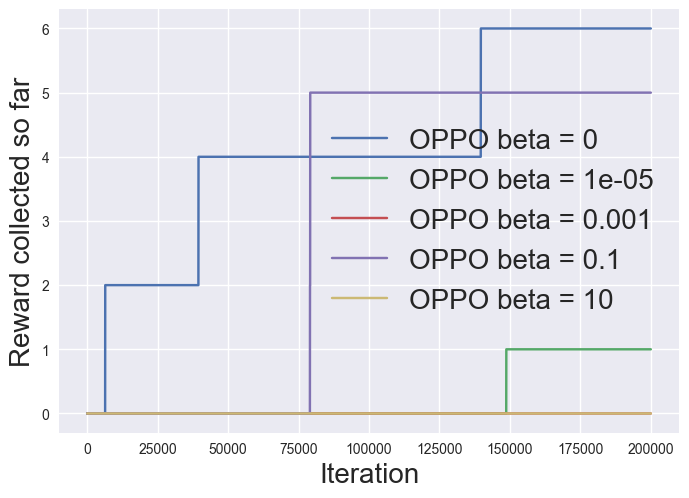

In [12]:
labels = [ f"OPPO beta = {beta}" for beta in betas]
plot_lines(
    to_plot,
    labels,
    ["Iteration", "Reward collected so far"],
    "figs",
    "ucbvseps",
    show=True
)

**Question**

Why does setting $\beta = 0$ lead to bad results? 

*Hint: Explain using the remarks in slide 28 and the theoretical bound in Slide 22 of Lecture 5*.

**Answer**

From the plot we observe that with $\beta=0$ the agent collects almost no reward over the whole run. Setting $\beta=0$ kills the exploration bonus and brings OPPO back to a vanilla sample‑based NPG, and that is exactly the regime that breaks down in this MDP. We can see this in three connected ways:

**1. No optimism in the face of uncertainty (Slide 28).** The bonus is designed precisely to upper‑bound the model error,
$$
\Bigl|\sum_{s'}\bigl(\hat P_h(s'|s,a)-P_h(s'|s,a)\bigr)V(s')\Bigr|\;\le\;\mathrm{bonus}_h(s,a).
$$
With $\beta=0$ the right‑hand side collapses to $0$, so we are implicitly trusting our empirical transitions $\hat P$ as if they were exact. As a result, the algorithm has no incentive to visit state–action pairs whose model is still uncertain, and many cells of the gridworld are simply never explored from the bottom‑right corner.

**2. Unbounded mismatch coefficient (Slide 22).** As we showed in the previous question, here
$$
\kappa\;=\;\Bigl\|\frac{\lambda^\pi}{\mu}\Bigr\|_\infty\;=\;+\infty,
$$
because $\mu$ puts all its mass on a single cell. The standard NPG bound on Slide 22 scales with this $\kappa$, so without exploration we have no convergence guarantee at all in this environment.

**3. Degraded theoretical guarantee.** The performance bound for sample‑based NPG,
$$
\mathbb E\!\left[\min_{t\le T} J(\pi^\star)-J(\pi_t)\right]\;\le\;\mathcal O\!\left(\sqrt{\kappa\,\epsilon_{\mathrm{stat}}}+\sqrt{\epsilon_{\mathrm{bias}}}\right),
$$
becomes vacuous once $\kappa=+\infty$, which is precisely what happens when we drop the bonus. OPPO is built specifically to remove this $\kappa$ dependence by using the bonus to drive coverage on its own — and turning the bonus off ($\beta=0$) gives back exactly the failure mode it was designed to avoid.

**Question**

Why does setting $\beta$ too large lead to poor results?

*Hint: Answer using the regret bound for OPPO given at the beginning of slide 30.*

**Answer**

Setting $\beta$ too large is just as harmful as setting it to $0$, only for the opposite reason. We observe in the plot that for $\beta=10$ the cumulative reward stays well below the curves obtained with $\beta\in\{10^{-5},10^{-3},0.1\}$, even though $\beta=10$ does provide exploration.

The reason is that the bonus $\mathrm{bonus}_h^t(s,a)\propto\beta/\sqrt{N_h^t(s,a)+1}$ then completely dominates the actual estimated $Q$‑values inside the softmax update, and the policy keeps committing to actions that look attractive only because they are still uncertain. The agent ends up *chasing uncertainty* instead of reward, so even after many episodes it doesn't settle on a near‑optimal policy.

This intuition is captured directly by the OPPO regret bound at the beginning of Slide 30:
$$
\sum_{t=1}^{T}\bigl(V^\star(s_1)-V^{\pi^t}(s_1)\bigr)\;\le\;\mathcal O\!\left(\sum_{h=1}^{H}\sum_{t=1}^{T}\mathrm{bonus}_h^t(s_h^t,a_h^t)\right).
$$
The right‑hand side is *linear* in $\beta$ (since the bonus itself is $\propto\beta$), so making $\beta$ large directly inflates the regret upper bound: we are guaranteed nothing better than a regret that grows linearly with $\beta$. In short, exploration is necessary, but only the right *amount* of it pays off — too little ($\beta=0$) makes the bound on $\hat P-P$ fail, too much ($\beta=10$) makes the regret bound itself loose, and the empirical sweet spot in our plot is around $\beta\in[10^{-3},10^{-1}]$.

# Ex 4: REINFORCE with parametrized policies (20 points)

In this exercise, we will investigate the effect of choosing different baselines in the reinforce implementation.
This topic is covered from Slide 31 on in Lecture 5.

**Hint: You may want to use Google Colab to run the experiments faster, but you don't have to.**

### Import the Necessary Packages

In [13]:
# TODO: you may need to run this to make sure to have the correct versions
!pip install gym==0.25.2
!pip install gym-notices==0.0.8


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
import gym
import numpy as np
from collections import deque
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (16, 10)

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical
torch.manual_seed(0)

import base64, io

# For visualization
from gym.wrappers.monitoring import video_recorder
from IPython.display import HTML
from IPython import display
import glob

In [15]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

### Instantiate the Environment and Agent

The CartPole environment is very simple. It has discrete action space (2) and 4 dimensional state space.

In [16]:
env = gym.make('CartPole-v0')
env.seed(0)

c:\Users\Kevin\AppData\Local\Programs\Python\Python312\Lib\site-packages\gym\envs\registration.py:593: UserWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.warn(
c:\Users\Kevin\AppData\Local\Programs\Python\Python312\Lib\site-packages\gym\core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
c:\Users\Kevin\AppData\Local\Programs\Python\Python312\Lib\site-packages\gym\wrappers\step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
c:\Users\Kevin\AppData\Local\Programs\Python\Python312\Lib\site-packages\gym\core.py:256: DeprecationWar

[0]

In [17]:
class Policy(nn.Module): # definie the policy network
    def __init__(self, state_size=4, action_size=2, hidden_size=32):
        super(Policy, self).__init__()
        self.fc1 = nn.Linear(state_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, action_size)

    def forward(self, state):
        x = F.relu(self.fc1(state))
        x = self.fc2(x)
        return F.softmax(x, dim=1) # we just consider 1 dimensional probability of action

    def act(self, state):
        state = torch.from_numpy(state).float().unsqueeze(0).to(device)
        probs = self.forward(state).cpu()
        model = Categorical(probs)
        action = model.sample()
        return action.item(), model.log_prob(action)
    

In [18]:
# REINFORCE (with reward-to-go)
# --> with gradient estimator according to version 2 of the PG theorem (not using Q-values, but reward to go)
def reinforce_rwd2go(policy, optimizer, early_stop=False, n_episodes=1000, max_t=1000, gamma=1.0, print_every=100):
    scores_deque = deque(maxlen=100)
    scores = []
    for e in range(1, n_episodes):
        saved_log_probs = []
        rewards = []
        state = env.reset()
        # Collect trajectory
        for t in range(max_t):
            # Sample the action from current policy
            action, log_prob = policy.act(state)
            saved_log_probs.append(log_prob)
            state, reward, done, _ = env.step(action)
            rewards.append(reward)
            if done:
                break
        # Calculate total expected reward
        scores_deque.append(sum(rewards))
        scores.append(sum(rewards))

        # Recalculate the total reward applying discounted factor
        discounts = [gamma ** i for i in range(len(rewards) + 1)]
        rewards_to_go = [sum([discounts[j]*rewards[j+t] for j in range(len(rewards)-t) ]) for t in range(len(rewards))]

        # Calculate the loss
        policy_loss = []
        for i in range(len(saved_log_probs)):
            log_prob = saved_log_probs[i]
            G = rewards_to_go[i]
            # Note that we are using Gradient Ascent, not Descent. So we need to calculate it with negative rewards.
            policy_loss.append(-log_prob * G)
        # After that, we concatenate whole policy loss in 0th dimension
        policy_loss = torch.cat(policy_loss).sum()

        # Backpropagation
        optimizer.zero_grad()
        policy_loss.backward()
        optimizer.step()

        if e % print_every == 0:
            print('Episode {}\tAverage Score: {:.2f}'.format(e, np.mean(scores_deque)))
        if early_stop and np.mean(scores_deque) >= 195.0:
            print('Environment solved in {:d} episodes!\tAverage Score: {:.2f}'.format(e - 100, np.mean(scores_deque)))
            break
    return scores

**Question**

1. Find **two** good baselines that improve over the implementation of REINFORCE without baseline. You should plot their results below.

You can take inspiration from the Example Notebook we attached for lecture 4, but you **cannot use exactly the same**.

2. Explain why you chose your baselines and why you think they are reasonable.

*Note:* You may also change other parameters such as the learning rate, as long as you clearly state it in your response.

**Answer**

The CartPole state is $[x,\,\dot x,\,\theta,\,\dot\theta]$ (cart position, cart velocity, pole angle, pole angular velocity). A baseline reduces variance when it approximates $V^\pi(s)$, i.e. when it correlates with how long the pole will stay balanced from state $s$.

**Baseline 1: angle and angular velocity.**
The naive baseline only uses $\theta$. Adding $\dot\theta$ captures the momentum of the pole: a small angle with high angular velocity is more dangerous than a larger angle that is nearly stationary. This is a strictly better predictor of the remaining return.

**Baseline 2: full four-dimensional state.**
Including the cart position and velocity further improves the approximation. The cart must stay within $|x|\le 2.4$; being near the boundary shortens the episode regardless of the pole angle, and high $|\dot x|$ predicts an imminent boundary violation. Using all four components gives the richest hand-crafted approximation of $V^\pi(s)$ and should reduce variance the most.

In [ ]:
def naive_baseline(state): # Example Baseline from lecture 4 (for inspiration)
    angle = state[2]
    value = 100 * (0.25 - angle**2)
    return value

def baseline_1(state):
    # Naive baseline modulated by angular velocity: the factor (1 - 0.05*|ang_vel|)
    # stays in [~0.7, 1.0], so the baseline ranges roughly in [18, 25] -- close
    # to V^pi of a random policy (~22 episode length) and never collapses to 0.
    angle, ang_vel = state[2], state[3]
    return 100 * (0.25 - angle**2) * (1.0 - 0.05 * abs(ang_vel))

def baseline_2(state):
    # Same idea, but uses all 4 state components.
    pos, vel, angle, ang_vel = state
    return (100 * (0.25 - angle**2)
            * (1.0 - 0.05 * abs(ang_vel))
            * (1.0 - 0.05 * abs(pos))
            * (1.0 - 0.05 * abs(vel)))


# PLOT 3: reward-to-go with baseline REINFORCE
# --> with gradient estimator according to version 3 of the PG theorem (not using Q-values, but reward to go)
# --> here, we consider only fixed (handcrafted) baseline functions b : S -> R; clearly, training a NN to predict V^{\pi}(s) as a baseline is also possible (and interesting!)
def reinforce_rwd2go_baseline(policy, optimizer, early_stop=False, baseline=naive_baseline, n_episodes=1000, max_t=1000, gamma=1.0, print_every=100):
    scores_deque = deque(maxlen=100)
    scores = []
    for e in range(1, n_episodes):
        saved_log_probs = []
        rewards = []
        baseline_values = []
        state = env.reset()
        for t in range(max_t):
            action, log_prob = policy.act(state)
            saved_log_probs.append(log_prob)
            state, reward, done, _ = env.step(action)
            rewards.append(reward)
            baseline_values.append(baseline(state))
            if done:
                break
        scores_deque.append(sum(rewards))
        scores.append(sum(rewards))

        discounts = [gamma ** i for i in range(len(rewards) + 1)]
        rewards_to_go = [sum([discounts[j]*rewards[j+t] for j in range(len(rewards)-t)]) for t in range(len(rewards))]

        policy_loss = []
        for i in range(len(saved_log_probs)):
            log_prob = saved_log_probs[i]
            G_centered = rewards_to_go[i] - baseline_values[i]
            policy_loss.append(-log_prob * G_centered)
        policy_loss = torch.cat(policy_loss).sum()

        optimizer.zero_grad()
        policy_loss.backward()
        optimizer.step()

        if e % print_every == 0:
            print('Episode {}\tAverage Score: {:.2f}'.format(e, np.mean(scores_deque)))
        if early_stop and np.mean(scores_deque) >= 195.0:
            print('Environment solved in {:d} episodes!\tAverage Score: {:.2f}'.format(e - 100, np.mean(scores_deque)))
            break
    return scores


In [23]:
env = gym.make('CartPole-v0')
env.seed(0)

# PLOT 1: run REINFORCE
policy_rwd2go = Policy().to(device)
optimizer_rwd2go = optim.Adam(policy_rwd2go.parameters(), lr=1e-2)
scores_rwd2go = reinforce_rwd2go(policy_rwd2go, optimizer_rwd2go, early_stop=False, n_episodes=2000)

env = gym.make('CartPole-v0')
env.seed(0)

# PLOT 2: run REINFORCE and YOUR baseline 1
policy_baseline_1 = Policy().to(device)
optimizer_baseline_1 = optim.Adam(policy_baseline_1.parameters(), lr=1e-2)
scores_baseline_1 = reinforce_rwd2go_baseline(policy_baseline_1, optimizer_baseline_1, baseline=baseline_1, early_stop=False, n_episodes=2000)

env = gym.make('CartPole-v0')
env.seed(0)

# PLOT 3: run REINFORCE and YOUR baseline 2
policy_baseline_2 = Policy().to(device)
optimizer_baseline_2 = optim.Adam(policy_baseline_2.parameters(), lr=1e-2)
scores_baseline_2 = reinforce_rwd2go_baseline(policy_baseline_2, optimizer_baseline_2, baseline=baseline_2, early_stop=False, n_episodes=2000)

Episode 100	Average Score: 74.94
Episode 200	Average Score: 183.39
Episode 300	Average Score: 137.90
Episode 400	Average Score: 139.55
Episode 500	Average Score: 179.49
Episode 600	Average Score: 172.93
Episode 700	Average Score: 155.18
Episode 800	Average Score: 200.00
Episode 900	Average Score: 195.08
Episode 1000	Average Score: 191.13
Episode 1100	Average Score: 192.38
Episode 1200	Average Score: 179.02
Episode 1300	Average Score: 198.98
Episode 1400	Average Score: 200.00
Episode 1500	Average Score: 200.00
Episode 1600	Average Score: 199.51
Episode 1700	Average Score: 200.00
Episode 1800	Average Score: 200.00
Episode 1900	Average Score: 100.44
Episode 100	Average Score: 11.39
Episode 200	Average Score: 9.48
Episode 300	Average Score: 9.43
Episode 400	Average Score: 9.28
Episode 500	Average Score: 9.69
Episode 600	Average Score: 9.49
Episode 700	Average Score: 9.56
Episode 800	Average Score: 9.49
Episode 900	Average Score: 9.26
Episode 1000	Average Score: 9.45
Episode 1100	Average Sc

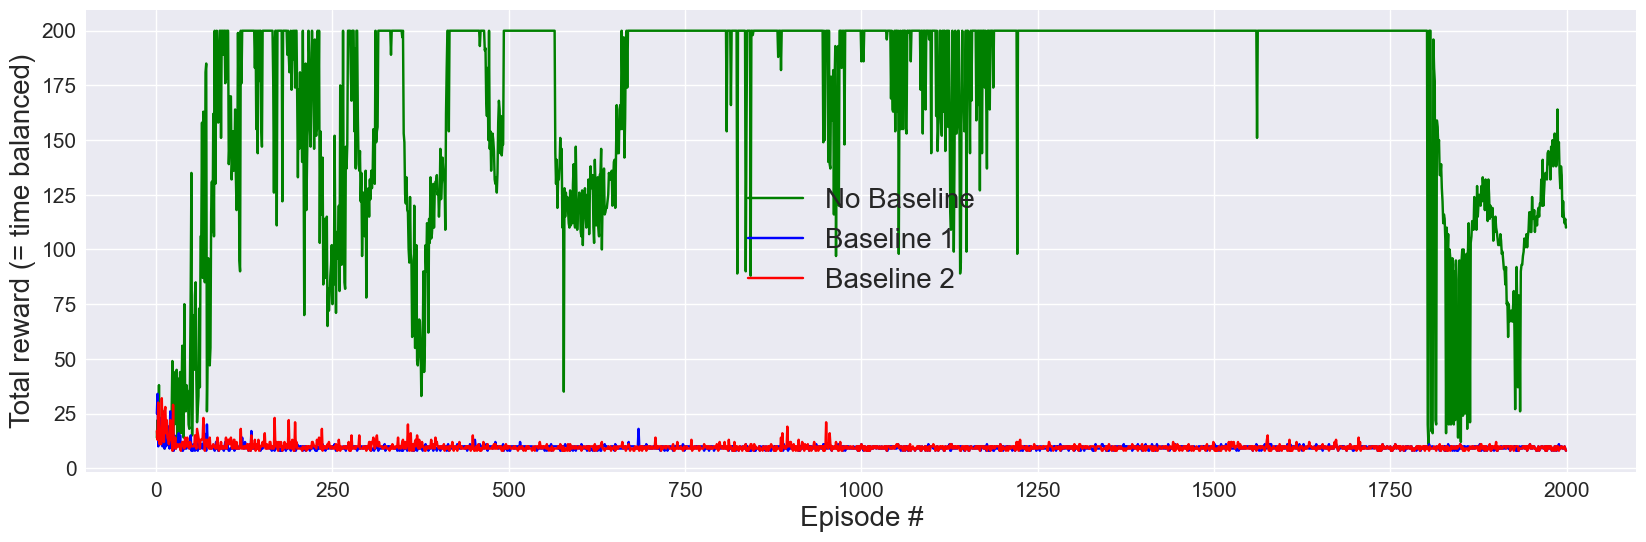

In [24]:
### Plot the learning progress

# Create the plot
fig = plt.figure(figsize=(20, 6))
ax = fig.add_subplot(111)

# Plot the scores with specified colors and labels
ax.plot(np.arange(1, len(scores_rwd2go) + 1), scores_rwd2go, color='green', label='No Baseline')
ax.plot(np.arange(1, len(scores_baseline_1) + 1), scores_baseline_1, color='blue', label='Baseline 1')
ax.plot(np.arange(1, len(scores_baseline_2) + 1), scores_baseline_2, color='red', label='Baseline 2')

# Set the labels with a larger font size
ax.set_ylabel('Total reward (= time balanced)', fontsize=20)
ax.set_xlabel('Episode #', fontsize=20)

# Set the tick labels to a larger font size
ax.tick_params(axis='both', which='major', labelsize=15)

# Add a legend with a specified font size
ax.legend(fontsize=20)

# Show the plot
plt.show()

# $Q^\star$: Policy Gradient with continuous actions and bound on the bonuses count in OPPO (20 points)
***Question 1:*** Consider using a Gaussian parameterized policy $\pi_{\mu,\Sigma}$ with mean $\mu \in \mathrm{R}^d$ 
and covariance matrix $\Sigma$ . Write down the following gradients:

$$ \nabla_\mu J(\pi_{\mu, \Sigma}) = ???$$
$$ \nabla_\Sigma J(\pi_{\mu, \Sigma}) = ???$$
***Question 2*** In this exercise, you will bound the state action counts. This is a crucial part of the OPPO convergence proof. Let $N^t_h(s,a)$ denotes the number of times the state action pair $s,a$ has been visited at step $h$ in all the episode up to $t$ included. Moreover,
let $s^t_h,a^t_h$ be the state action pair visited at step $h$ of the $t^{th}$ episode. Then, prove that 
$$ \sum^T_{t=1} \sum^H_{h=1} \frac{1}{N^t_h(s^t_h, a^t_h)+1} \leq SAH \log( T H)$$
***Question 3*** Use the fact above to prove the following bound at slide 30 of Lecture 5. That is, for $\mathrm{bonus}^t_h(s,a) = \frac{H}{\sqrt{N^t_h(s,a)+1}}$ it holds that
$$ \sum^T_{t=1} \sum^H_{h=1} \mathrm{bonus}(s^t_h, a^t_h) \leq H^2\sqrt{ SA T \log( T H)}$$

**Answer 1**

The Gaussian density is
$$
\pi_{\mu,\Sigma}(a\mid s) \;=\; (2\pi)^{-d/2}(\det\Sigma)^{-1/2}\exp\!\Bigl(-\tfrac{1}{2}(a-\mu)^{\top}\Sigma^{-1}(a-\mu)\Bigr),
$$
so the log-likelihood reads
$$
\log\pi_{\mu,\Sigma}(a\mid s) \;=\; -\tfrac{d}{2}\log(2\pi)\;-\;\tfrac{1}{2}\log\det\Sigma\;-\;\tfrac{1}{2}(a-\mu)^{\top}\Sigma^{-1}(a-\mu).
$$
Differentiating gives
$$
\nabla_{\mu}\log\pi_{\mu,\Sigma}(a\mid s) \;=\; \Sigma^{-1}(a-\mu),\qquad
\nabla_{\Sigma}\log\pi_{\mu,\Sigma}(a\mid s) \;=\; \tfrac{1}{2}\,\Sigma^{-1}\!\bigl[(a-\mu)(a-\mu)^{\top}-\Sigma\bigr]\Sigma^{-1},
$$
where we used $\nabla_{\Sigma}\log\det\Sigma=\Sigma^{-1}$ and $\nabla_{\Sigma}(a-\mu)^{\top}\Sigma^{-1}(a-\mu)=-\Sigma^{-1}(a-\mu)(a-\mu)^{\top}\Sigma^{-1}$.

Plugging these expressions into the policy-gradient theorem,
$$
\nabla_{\theta}J(\pi_{\theta})\;=\;\frac{1}{1-\gamma}\,\mathbb{E}_{(s,a)\sim\lambda^{\pi_{\theta}}}\!\bigl[\,Q^{\pi_{\theta}}(s,a)\,\nabla_{\theta}\log\pi_{\theta}(a\mid s)\,\bigr],
$$
yields
$$
\boxed{\;\nabla_{\mu}J(\pi_{\mu,\Sigma})\;=\;\frac{1}{1-\gamma}\,\mathbb{E}_{(s,a)\sim\lambda^{\pi}}\!\bigl[\,Q^{\pi}(s,a)\,\Sigma^{-1}(a-\mu)\,\bigr]\;}
$$
$$
\boxed{\;\nabla_{\Sigma}J(\pi_{\mu,\Sigma})\;=\;\frac{1}{2(1-\gamma)}\,\mathbb{E}_{(s,a)\sim\lambda^{\pi}}\!\Bigl[\,Q^{\pi}(s,a)\,\Sigma^{-1}\!\bigl((a-\mu)(a-\mu)^{\top}-\Sigma\bigr)\Sigma^{-1}\,\Bigr]\;}
$$

**Answer 2**

Fix a step index $h\in[H]$. At each episode $t\in[T]$, exactly one pair is visited at step $h$, namely $(s^{t}_{h},a^{t}_{h})$. For any pair $(s,a)\in\mathcal{S}\times\mathcal{A}$, let $n_{h}(s,a):=N^{T}_{h}(s,a)$ be its total number of visits at step $h$ over the $T$ episodes; by construction
$$
\sum_{(s,a)\in\mathcal{S}\times\mathcal{A}} n_{h}(s,a)\;=\;T.
$$

The successive visits to a fixed $(s,a)$ at step $h$ produce values $N^{t}_{h}(s,a)+1=2,3,\dots,n_{h}(s,a)+1$, hence
$$
\sum_{\substack{t=1\\(s^{t}_{h},a^{t}_{h})=(s,a)}}^{T}\!\!\frac{1}{N^{t}_{h}(s^{t}_{h},a^{t}_{h})+1}\;=\;\sum_{k=1}^{n_{h}(s,a)}\frac{1}{k+1}\;\le\;\int_{1}^{n_{h}(s,a)+1}\!\!\frac{dx}{x}\;=\;\log\bigl(n_{h}(s,a)+1\bigr).
$$

Summing over $(s,a)$ and applying Jensen's inequality to the concave function $x\mapsto\log(x+1)$, together with $\sum_{(s,a)}n_{h}(s,a)=T$,
$$
\sum_{t=1}^{T}\frac{1}{N^{t}_{h}(s^{t}_{h},a^{t}_{h})+1}\;\le\;\sum_{(s,a)}\log\bigl(n_{h}(s,a)+1\bigr)\;\le\;SA\,\log\!\Bigl(\tfrac{T}{SA}+1\Bigr)\;\le\;SA\,\log(TH).
$$

Finally, summing over $h\in[H]$,
$$
\sum_{t=1}^{T}\sum_{h=1}^{H}\frac{1}{N^{t}_{h}(s^{t}_{h},a^{t}_{h})+1}\;\le\;SAH\,\log(TH).\qquad\blacksquare
$$

**Answer 3**

With $\mathrm{bonus}^{t}_{h}(s,a)=H/\sqrt{N^{t}_{h}(s,a)+1}$, factor out $H$ and apply the Cauchy-Schwarz inequality to the $TH$ terms $1/\sqrt{N^{t}_{h}(s^{t}_{h},a^{t}_{h})+1}$:
$$
\sum_{t=1}^{T}\sum_{h=1}^{H}\mathrm{bonus}^{t}_{h}(s^{t}_{h},a^{t}_{h})\;=\;H\sum_{t=1}^{T}\sum_{h=1}^{H}\frac{1}{\sqrt{N^{t}_{h}(s^{t}_{h},a^{t}_{h})+1}}\;\le\;H\sqrt{TH}\,\sqrt{\sum_{t=1}^{T}\sum_{h=1}^{H}\frac{1}{N^{t}_{h}(s^{t}_{h},a^{t}_{h})+1}}.
$$

Inserting the bound from Answer 2,
$$
H\sqrt{TH}\,\sqrt{SAH\,\log(TH)}\;=\;H\,\sqrt{SAH^{2}T\,\log(TH)}\;=\;H^{2}\sqrt{SAT\,\log(TH)}.
$$

Therefore
$$
\boxed{\;\sum_{t=1}^{T}\sum_{h=1}^{H}\mathrm{bonus}^{t}_{h}(s^{t}_{h},a^{t}_{h})\;\le\;H^{2}\sqrt{SAT\,\log(TH)}.\;}\qquad\blacksquare
$$